<a href="https://colab.research.google.com/github/Zzuzzolo18/Deep-Learning---Pytorch/blob/main/Ottimizzazione_delle_prestazioni_di_una_rete_neurale_per_il_settore_food.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Consegna
GourmetAI Inc., una rinomata azienda nel settore della tecnologia alimentare, si trova ad affrontare sfide crescenti nel migliorare l'accuratezza e l'efficienza dei sistemi di classificazione delle immagini di cibo. La necessità di fornire ai clienti soluzioni avanzate e di alta qualità per identificare e categorizzare correttamente i cibi è essenziale per migliorare l'esperienza utente e ottimizzare i processi aziendali.

**Benefici del Progetto**: L'implementazione di tecniche avanzate di deep learning per la classificazione delle immagini di cibo offre numerosi vantaggi:

*  Miglioramento dell'Esperienza Utente: Un sistema preciso e affidabile migliora significativamente l'esperienza degli utenti nelle applicazioni di riconoscimento di immagini di cibo, fornendo risultati rapidi e accurati.
*  Ottimizzazione dei Processi Aziendali: Automatizzare la classificazione delle immagini riduce il tempo e le risorse necessarie per identificare e categorizzare i cibi, migliorando l'efficienza operativa complessiva.
*  Innovazione Tecnologica: Utilizzare tecniche avanzate di deep learning promuove l'innovazione all'interno dell'azienda, consentendo di affrontare sfide complesse nel settore del riconoscimento delle immagini.
*  Obiettivi di Business: Migliorare le performance dei modelli di classificazione aiuta GourmetAI Inc. a soddisfare gli obiettivi di business, consolidando la propria posizione come leader nel settore della tecnologia alimentare.

Dettagli del Progetto: GourmetAI Inc. ha richiesto lo sviluppo di un modello avanzato di classificazione di immagini di cibo utilizzando tecniche di deep learning. Il progetto si baserà sul dataset Food Classification, arricchito con tecniche di augmentation per migliorare la diversità e la qualità dei dati disponibili.

**Obiettivi del Progetto**:

1. Strategie di Augmentation: Implementare diverse tecniche di augmentation per arricchire il dataset, migliorando la variabilità e la qualità dei dati.
Divisione del Dataset: Suddividere il dataset in trainset, valset e testset per garantire un'adeguata formazione e validazione del modello.
2. Architetture di Rete e Transfer Learning: Selezionare e implementare una o più architetture di rete neurale adatte al problema, utilizzando il transfer learning per sfruttare modelli pre-addestrati.
3. Fine Tuning e Scelta degli Hyperparameters: Creare un classificatore personalizzato, scegliere gli hyperparameters e ottimizzare il modello attraverso processi di training e validation.
4. Validation e Regolarizzazione: Utilizzare tecniche di validation per migliorare la scelta degli hyperparameters e risolvere potenziali problemi con tecniche di regolarizzazione.
5. Test Finale: Eseguire un test finale per verificare le capacità di generalizzazione del modello e raggiungere le performance desiderate.

**Fasi del Progetto**:

*  Sviluppo delle Strategie di Augmentation: Esplorazione e implementazione di tecniche di augmentation per arricchire il dataset.
*  Preparazione del Dataset: Divisione del dataset in trainset, valset e testset; preparazione degli strumenti per l'utilizzo delle immagini come input.
*  Selezione e Implementazione delle Architetture: Scelta e implementazione di architetture di rete neurale, applicando il transfer learning.
*  Fine Tuning e Scelta degli Hyperparameters: Creazione di un classificatore personalizzato, selezione degli hyperparameters e ottimizzazione del modello.
*  Validation e Regolarizzazione: Ripetizione del training con tecniche di validation e regolarizzazione per migliorare le performance del modello.
*  Test Finale: Esecuzione di un test finale per valutare le capacità di generalizzazione del modello e confrontare i risultati con le aspettative.
*  Motivazione del Progetto: Per GourmetAI Inc., la precisione nella classificazione delle immagini di cibo rappresenta un requisito fondamentale. Migliorare l'efficacia dei sistemi di classificazione non solo migliora l'esperienza utente e ottimizza i processi aziendali, ma consente anche di consolidare la leadership nel settore della tecnologia alimentare attraverso l'innovazione tecnologica.

Con questo progetto, GourmetAI Inc. mira a sviluppare e implementare un sistema avanzato di classificazione di immagini di cibo, utilizzando tecniche all'avanguardia di deep learning per raggiungere performance superiori e soddisfare le esigenze specifiche del mercato.

## DATASET

Il dataset è disponibile al seguente link: https://proai-datasets.s3.eu-west-3.amazonaws.com/dataset_food_classification.zip

# Sviluppo del progetto

## Librerie

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary
from torchvision import datasets


import matplotlib.pyplot as plt
import numpy as np
import os
import random

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Seed

In [ ]:
# Random seed for reproducibility
seed = 1999

random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(0)

## Caricamneto Dataset

In [ ]:
import requests, zipfile, io
zip_file_url = 'https://proai-datasets.s3.eu-west-3.amazonaws.com/dataset_food_classification.zip'
r = requests.get(zip_file_url, stream=True)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("./dataset")

In [ ]:
! ls dataset/dataset/train/Donut | wc -l

640


Il dataset è già suddiviso in train, val e test.

In ogni cartella vi sono le suddivisioni per classe di cibi e al proprio interno ci sono 640 immagini in formato *jpeg*

In [ ]:
# normalizzazione
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

In [ ]:
# carico train e val
raw_train = datasets.ImageFolder(root='./dataset/dataset/train', transform=transform)
raw_val = datasets.ImageFolder(root='./dataset/dataset/val', transform=transform)

### Esplorazione

In [ ]:
raw_train.classes

['Baked Potato',
 'Crispy Chicken',
 'Donut',
 'Fries',
 'Hot Dog',
 'Sandwich',
 'Taco',
 'Taquito',
 'apple_pie',
 'cheesecake',
 'chicken_curry',
 'ice_cream',
 'omelette',
 'sushi']

In [ ]:
raw_train[0][0].shape

torch.Size([3, 512, 512])

Le immagini sono da 3 canali e 512x512

Visualizziamo la prima immagine

Etichetta: Baked Potato


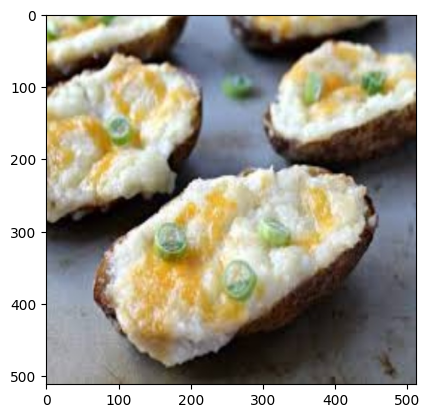

In [ ]:
img_tensor, label = raw_train[0]

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))


print(f"Etichetta: {raw_train.classes[label]}")
plt.imshow(imshow(img_tensor))
plt.show()

In [ ]:
iteration = 0

In [ ]:
classes = raw_train.classes

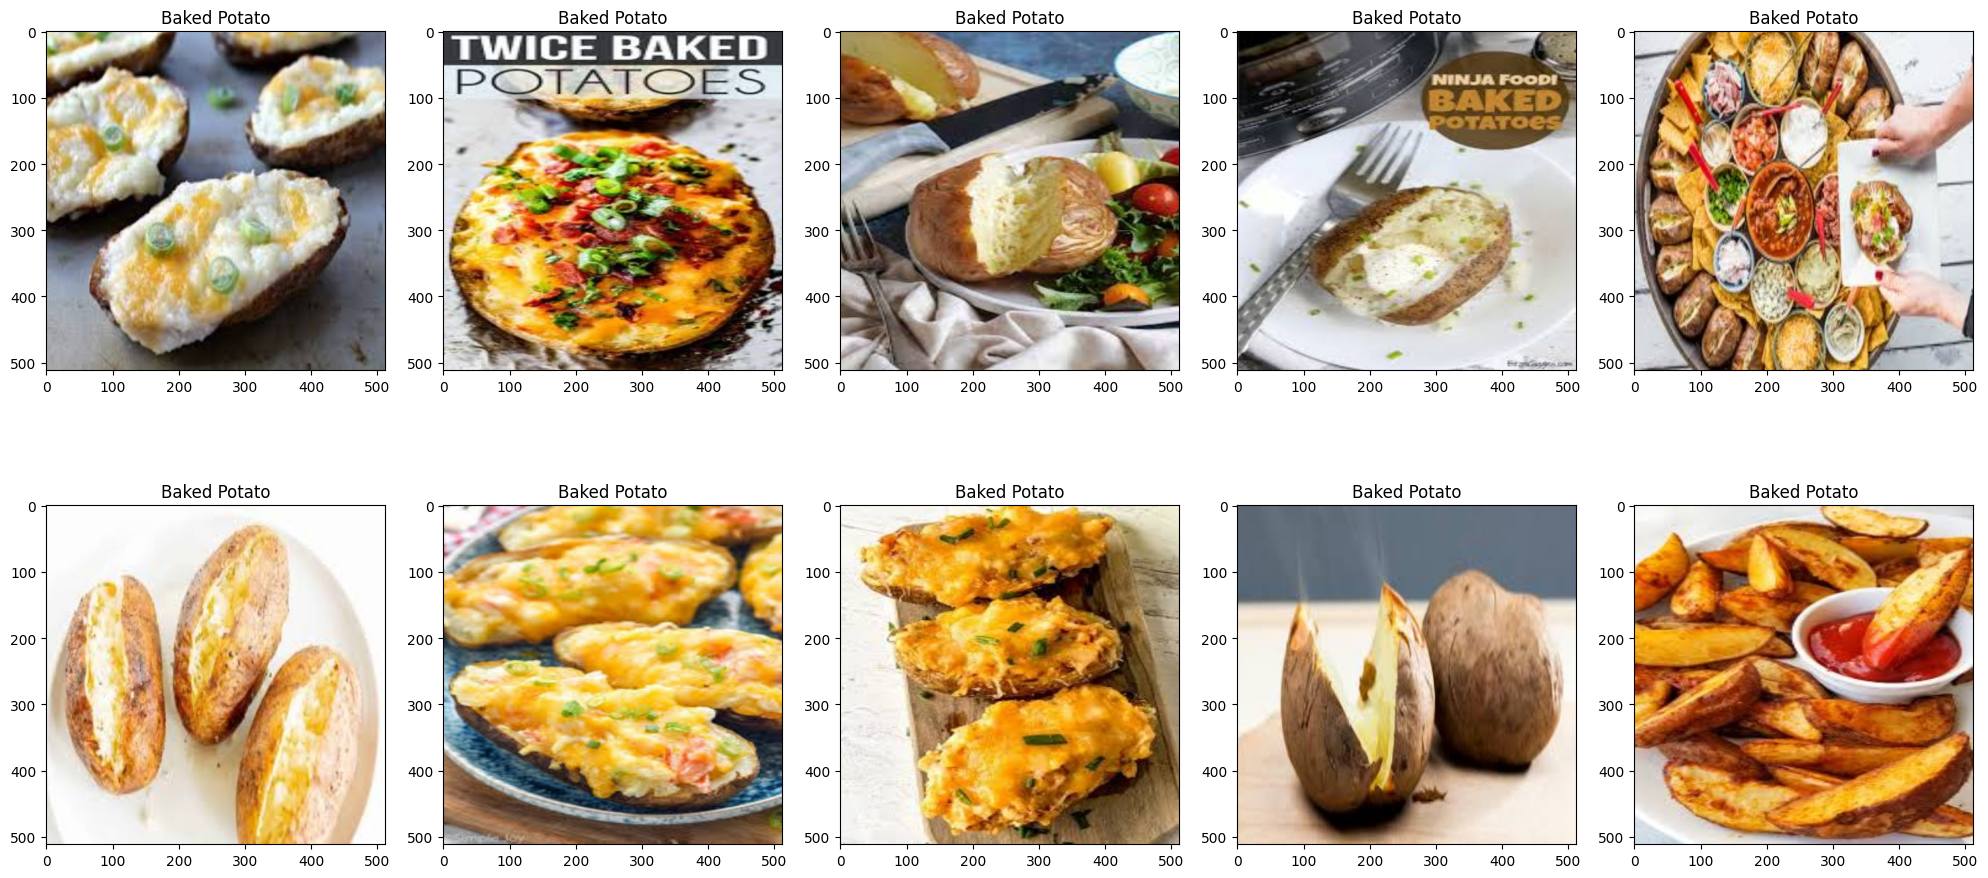

In [ ]:
num_row = 2
num_col = 5
fig, axes = plt.subplots(num_row, num_col, figsize=(10*num_row,2*num_col))
for i in range(num_row*num_col):
    ax = axes[i//num_col, i%num_col]
    ax.imshow(imshow(raw_train[iteration * num_row * num_col + i][0]))
    ax.set_title('{}'.format(classes[int(raw_train[iteration * num_row * num_col + i][1])]))
plt.tight_layout()
plt.show()
iteration += 1

## Preparo il Dataset

In [ ]:
trainset = torch.utils.data.DataLoader(raw_train, batch_size=32,
                                          shuffle=True)

valset = torch.utils.data.DataLoader(raw_val, batch_size=32,
                                          shuffle=True)

Preparo anche il testset

In [ ]:
raw_test = datasets.ImageFolder(root='./dataset/dataset/test', transform=transform)
testset = torch.utils.data.DataLoader(raw_test, batch_size=32,
                                          shuffle=True)

# Architettura

Vista la grandezza delle immagini e il numero delle classi, un allenamento da zero di un modello, sarebbe molto dispendioso.

Per questo utilizziamo il transferlearning.

Cercando in hugging face un modello affine al task ho trovato https://huggingface.co/nateraw/food da cui prenderò la parte convoluzionale.

Questo modello però prende in input immagini da 224x224, quindi vanno ridefiniti i set.
Inoltre, nelle specifiche c'è scritto che ha un batchsize da 128.

Mi adatto

In [ ]:
transform224 = transforms.Compose([
    # Ridimensioniamo a 224, che è lo standard per il modello nateraw/food
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # Usiamo le medie e deviazioni standard specifiche di ImageNet
    # (necessarie per quasi tutti i modelli pre-addestrati)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

raw_train224 = datasets.ImageFolder(root='./dataset/dataset/train', transform=transform224)
raw_val224 = datasets.ImageFolder(root='./dataset/dataset/val', transform=transform224)

trainset224 = torch.utils.data.DataLoader(raw_train224, batch_size=128,
                                          shuffle=True)

valset224 = torch.utils.data.DataLoader(raw_val224, batch_size=128,
                                          shuffle=True)

In [ ]:
from transformers import AutoModel
class FoodNet(nn.Module):
    def __init__(self, num_classes):
        super(FoodNet, self).__init__()

        # 1. Carichiamo il modello pre-addestrato da Hugging Face
        # Usiamo .from_pretrained per scaricare i pesi già istruiti sul cibo
        self.base_model = AutoModel.from_pretrained("nateraw/food")

        # 2. Congeliamo i pesi della parte convoluzionale (Transfer Learning)
        # In questo modo l'addestramento sarà velocissimo perché aggiorneremo solo il finale
        for param in self.base_model.parameters():
            param.requires_grad = False

        # 3. Definiamo la nostra testa classificatrice (Personalizzata)
        # Il modello Swin di nateraw ha una dimensione di uscita (hidden_size) di 768
        self.classifier = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes) # num_classes sarà il numero di cartelle nel tuo dataset
        )

    def forward(self, x):
        # Il modello Hugging Face restituisce un oggetto, noi prendiamo 'last_hidden_state'
        # e usiamo il primo token (o il pooler_output)
        outputs = self.base_model(x)

        # Estraiamo le caratteristiche globali (pooler_output è ideale per la classificazione)
        x = outputs.pooler_output

        # Passiamo le caratteristiche al nostro classificatore
        x = self.classifier(x)
        return x

# Inizializzazione
model = FoodNet(len(classes)).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/344M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: nateraw/food
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model

FoodNet(
  (base_model): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_fn

In [ ]:
#generata da gemini perchè il summary non funziona con il modello di hugginFace
def print_param_counts(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable

    print(f"--- Riepilogo Parametri ---")
    print(f"Totali:     {total:>12,}")
    print(f"Allenabili: {trainable:>12,}")
    print(f"Congelati:  {frozen:>12,}")
    print(f"---------------------------")

print_param_counts(model)

--- Riepilogo Parametri ---
Totali:       86,589,710
Allenabili:      200,462
Congelati:    86,389,248
---------------------------


Proviamo a fare un eval senza addestrare il modello

In [ ]:
correct = 0
total = 0

model.eval()
model.to(device)

# 2. Preleviamo un batch dal validation set
dataiter = iter(valset224)
images, labels = next(dataiter)

# 3. Spostiamo i dati sul device
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    for images, labels in valset224:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy totale sul Validation Set: {100 * correct / total:.2f}%")

Accuracy totale sul Validation Set: 9.42%


Perfetto, avendo 14 classi da predire e un accuratezza di circa il 10%, sappiamo che il modello sta tirando ad indovinare. Proprio come ci aspettavamo.

Ora possiamo provare ad allenarlo

## Allenamento

Prepariamo tutto il necessario per addestrare il modello.
Utilizzero la falsa riga di https://github.com/Profession-AI/materiale-pytorch/blob/main/6%20-%20Data%20Scarcity/Transfer%20Learning.ipynb

In [ ]:
class EarlyStopping:
    def __init__(self, save_path, patience=5, min_delta=0):

        self.save_path = save_path
        self.patience = patience
        self.min_delta = min_delta
        self.min_val_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, validation_loss, model):

        if self.min_val_loss is None:     #Prima epoca
          self.min_val_loss = validation_loss
          self.save_checkpoint(model)

        elif (self.min_val_loss - validation_loss) > self.min_delta: #Epoca con miglioramento
          self.min_val_loss = validation_loss
          self.save_checkpoint(model)
          self.counter = 0


        else:     #Nessun miglioramento
          self.counter +=1
          if self.counter >= self.patience:
            self.early_stop = True

    def save_checkpoint(self, model):
      torch.save(model.state_dict(), self.save_path)

In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    processed_data = 0

    for i, data in enumerate(train_loader, 0):
        inputs, labels = data[0].to(device), data[1].to(device) #[128, 256, 256], [128, 14]

        optimizer.zero_grad()

        outputs = model(inputs) #[128, 14]
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        processed_data += len(inputs)

    return running_loss / processed_data

In [ ]:
def test_epoch(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for i, data in enumerate(test_loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [ ]:
def train(model, train_loader, test_loader, criterion, optimizer, device, epochs=100, early_stopping=None):
    train_losses = []
    test_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_accuracy = test_epoch(model, test_loader, criterion, device)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Validation Loss: {test_loss:.4f}, Validation Accuracy: {test_accuracy:.4f}')

        if early_stopping is not None:
            early_stopping(test_loss, model)
            if early_stopping.early_stop:
                print("Early stopping")
                break

    return train_losses, test_losses, test_accuracies

Sfrutto anche il confusion matrix che torna utile per questo problema

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import json

In [ ]:
def plot_confusion_matrix(model, test_loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for i, data in enumerate(test_loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,7))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')

In [ ]:
model_save_folder = "models/baseline/"
os.makedirs(model_save_folder, exist_ok = True)
model_save_file = os.path.join(model_save_folder,"model.pt")
model_save_log = os.path.join(model_save_folder,"log.json")

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
early_stopping = EarlyStopping(model_save_file, patience=5, min_delta=0)
epochs = 100

In [ ]:
train_losses, test_losses, test_accuracies = train(model, trainset224, valset224, criterion, optimizer, device, epochs, early_stopping)
to_save_json = {"train_losses":train_losses,
            "test_losses":test_losses,
            "test_accuracies":test_accuracies}
with open(model_save_log, 'w') as f:
  json.dump(to_save_json, f)

Epoch 1/100, Train Loss: 0.0034, Validation Loss: 0.0033, Validation Accuracy: 0.8710
Epoch 2/100, Train Loss: 0.0028, Validation Loss: 0.0031, Validation Accuracy: 0.8781
Epoch 3/100, Train Loss: 0.0025, Validation Loss: 0.0030, Validation Accuracy: 0.8817
Epoch 4/100, Train Loss: 0.0022, Validation Loss: 0.0029, Validation Accuracy: 0.8915
Epoch 5/100, Train Loss: 0.0020, Validation Loss: 0.0029, Validation Accuracy: 0.8893
Epoch 6/100, Train Loss: 0.0018, Validation Loss: 0.0029, Validation Accuracy: 0.8862
Epoch 7/100, Train Loss: 0.0017, Validation Loss: 0.0029, Validation Accuracy: 0.8879
Epoch 8/100, Train Loss: 0.0015, Validation Loss: 0.0030, Validation Accuracy: 0.8866
Epoch 9/100, Train Loss: 0.0014, Validation Loss: 0.0029, Validation Accuracy: 0.8938
Epoch 10/100, Train Loss: 0.0013, Validation Loss: 0.0029, Validation Accuracy: 0.8938
Epoch 11/100, Train Loss: 0.0012, Validation Loss: 0.0030, Validation Accuracy: 0.8955
Epoch 12/100, Train Loss: 0.0011, Validation Loss: 0

In [ ]:
model.load_state_dict(torch.load(model_save_file))
with open(model_save_log, "r") as f:
    model_log = json.load(f)

In [ ]:
val_loss = model_log['test_losses'][-1]
val_accuracy = model_log['test_accuracies'][-1]
print("Accuracy on val set: ", val_accuracy)

Accuracy on val set:  0.8857142857142857


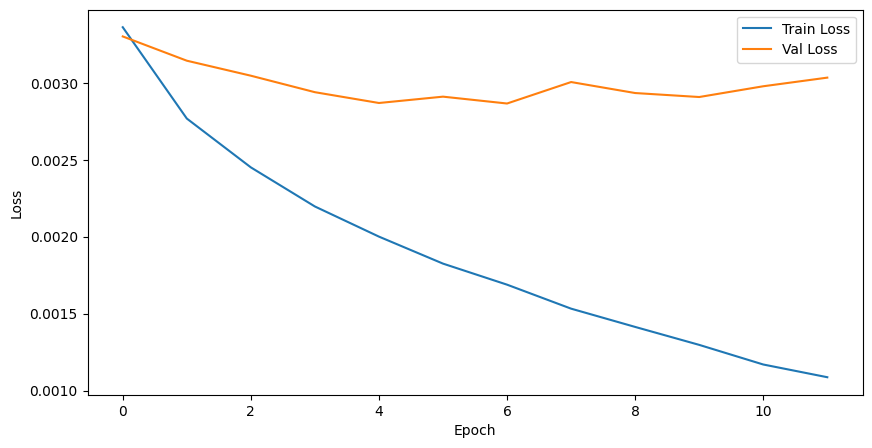

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(model_log['train_losses'], label='Train Loss')
plt.plot(model_log['test_losses'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

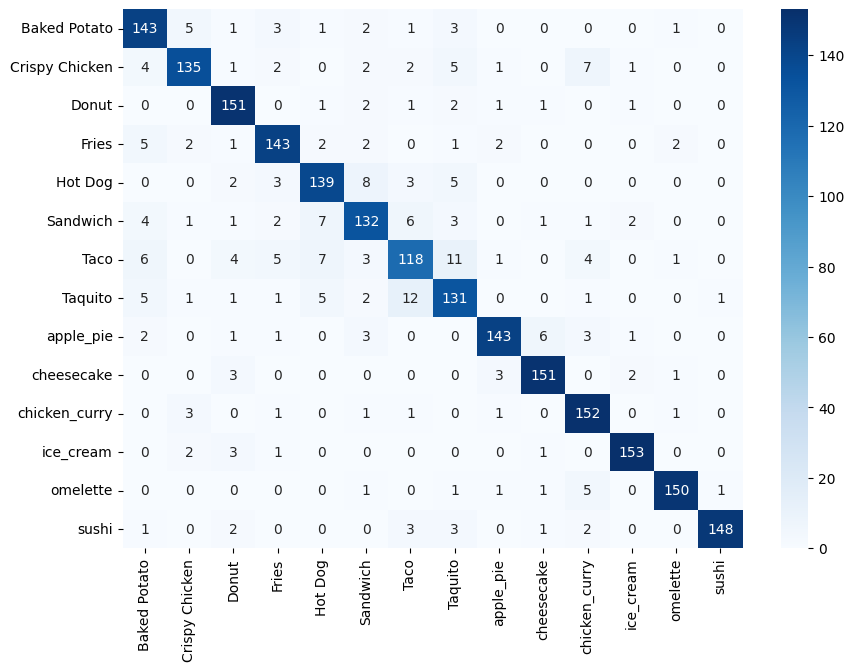

In [ ]:
plot_confusion_matrix(model, valset224, device)

Il modello raggiunge rapidamento un buon risultato di classificazione, generalizzando bene sul problema. Questo grazie alla prima parte del modello convoluzionale ereditato da un modello pretreinato.
È evidente che però rimangono dei problemi in cui il modello non riesce a distinguere correttamente alcune classi simili tra loro. Ad esempio, il taquito e il Taco, due pietanze che si assomigliano. Oppure ancora, il chicken_curry e Crispy_chicken, entrmabi pietanze a base di pollo. Le forme sicuramente si presentano in modi simili, per questo il modello ha difficoltà a distinguerle.

# Fine tuning del modello

Forziamo un po' di Data Augmentation

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # Specchiamo le immagini
    transforms.RandomRotation(15),          # Ruotiamo di 15 gradi
    transforms.ColorJitter(brightness=0.2), # Cambia un po' la luce
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
raw_train2 = datasets.ImageFolder(root='./dataset/dataset/train', transform=train_transform)
raw_val2 = datasets.ImageFolder(root='./dataset/dataset/val', transform=train_transform)

trainset2 = torch.utils.data.DataLoader(raw_train2, batch_size=128,
                                          shuffle=True)

valset2 = torch.utils.data.DataLoader(raw_val2, batch_size=128,
                                          shuffle=True)

In [ ]:
model2_save_folder = "models/baseline/"
os.makedirs(model2_save_folder, exist_ok = True)
model2_save_file = os.path.join(model2_save_folder,"model.pt")
model2_save_log = os.path.join(model2_save_folder,"log.json")

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
early_stopping = EarlyStopping(model2_save_file, patience=5, min_delta=0)
epochs = 100

In [ ]:
train_losses, test_losses, test_accuracies = train(model, trainset2, valset2, criterion, optimizer, device, epochs, early_stopping)
to_save_json = {"train_losses":train_losses,
            "test_losses":test_losses,
            "test_accuracies":test_accuracies}
with open(model2_save_log, 'w') as f:
  json.dump(to_save_json, f)

Epoch 1/100, Train Loss: 0.0087, Validation Loss: 0.0049, Validation Accuracy: 0.8116
Epoch 2/100, Train Loss: 0.0045, Validation Loss: 0.0045, Validation Accuracy: 0.8259
Epoch 3/100, Train Loss: 0.0041, Validation Loss: 0.0041, Validation Accuracy: 0.8393
Epoch 4/100, Train Loss: 0.0037, Validation Loss: 0.0040, Validation Accuracy: 0.8420
Epoch 5/100, Train Loss: 0.0035, Validation Loss: 0.0038, Validation Accuracy: 0.8527
Epoch 6/100, Train Loss: 0.0033, Validation Loss: 0.0038, Validation Accuracy: 0.8545
Epoch 7/100, Train Loss: 0.0032, Validation Loss: 0.0037, Validation Accuracy: 0.8580
Epoch 8/100, Train Loss: 0.0030, Validation Loss: 0.0037, Validation Accuracy: 0.8531
Epoch 9/100, Train Loss: 0.0030, Validation Loss: 0.0035, Validation Accuracy: 0.8580
Epoch 10/100, Train Loss: 0.0028, Validation Loss: 0.0036, Validation Accuracy: 0.8554
Epoch 11/100, Train Loss: 0.0027, Validation Loss: 0.0035, Validation Accuracy: 0.8585
Epoch 12/100, Train Loss: 0.0026, Validation Loss: 0

In [ ]:
model.load_state_dict(torch.load(model2_save_file))
with open(model2_save_log, "r") as f:
    model_log = json.load(f)

In [ ]:
val_loss = model_log['test_losses'][-1]
val_accuracy = model_log['test_accuracies'][-1]
print("Accuracy on val set: ", val_accuracy)

Accuracy on val set:  0.8678571428571429


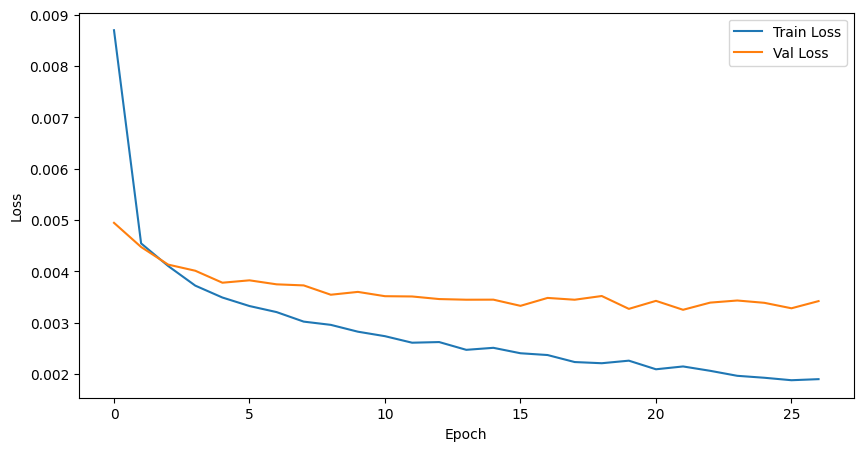

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(model_log['train_losses'], label='Train Loss')
plt.plot(model_log['test_losses'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

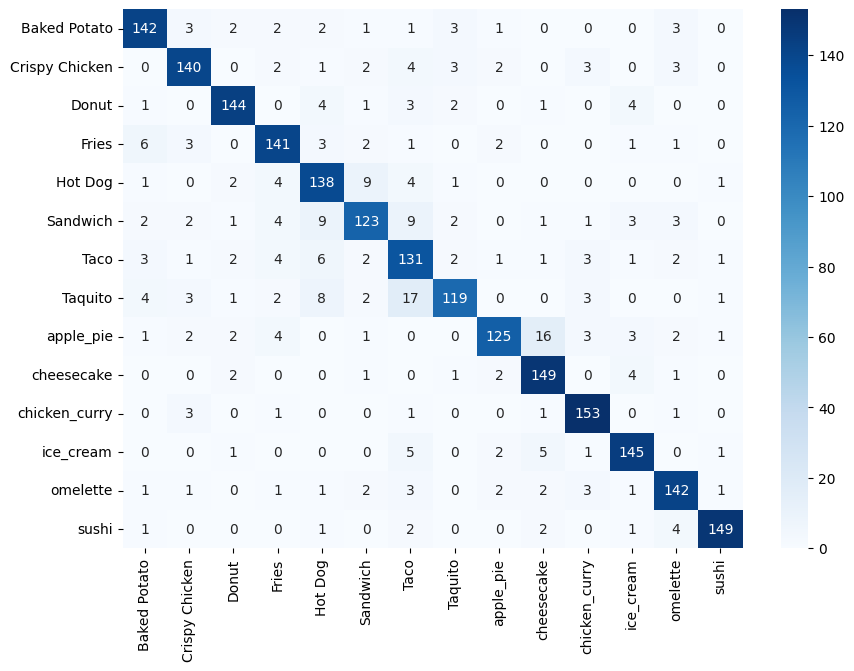

In [ ]:
plot_confusion_matrix(model, valset2, device)

Anche applicando una trasformazione dei dati di allenamento, non abbiamo ottenuto dei risultati migliori, anzi, hanno confuso ulteriolmente il modello sulle classi che già non riusciva a distinguere con precisione (citate prima).
Per capire esattamente quale trasformazione ha causato questo problema, avremmo bisogno di isolare le trasformazioni e ripetere la fase di training.

Ma visto che cuba del tempo rilevante teniamo per buono il modello iniziale e passiamo alla fase di valutazione del dataset di test.

# Valutazione delle prestazioni finale


In [ ]:
#preLoad del modello
path_al_modello = "models/baseline/model.pt"

state_dict = torch.load(path_al_modello, map_location=device)

model.load_state_dict(state_dict)

model.eval()

FoodNet(
  (base_model): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermediate_act_fn

In [ ]:
def test(model, test_loader, criterion, device):
    #train_losses = []
    test_losses = []
    test_accuracies = []

    test_loss, test_accuracy = test_epoch(model, test_loader, criterion, device)

    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

    return test_losses, test_accuracies

In [ ]:
raw_test = datasets.ImageFolder(root='./dataset/dataset/test', transform=transform224)

testset = torch.utils.data.DataLoader(raw_test, batch_size=128,
                                          shuffle=True)

In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
test_losses, test_accuracies = test(model, testset, criterion, device)

Test Loss: 0.0028, Test Accuracy: 0.8954


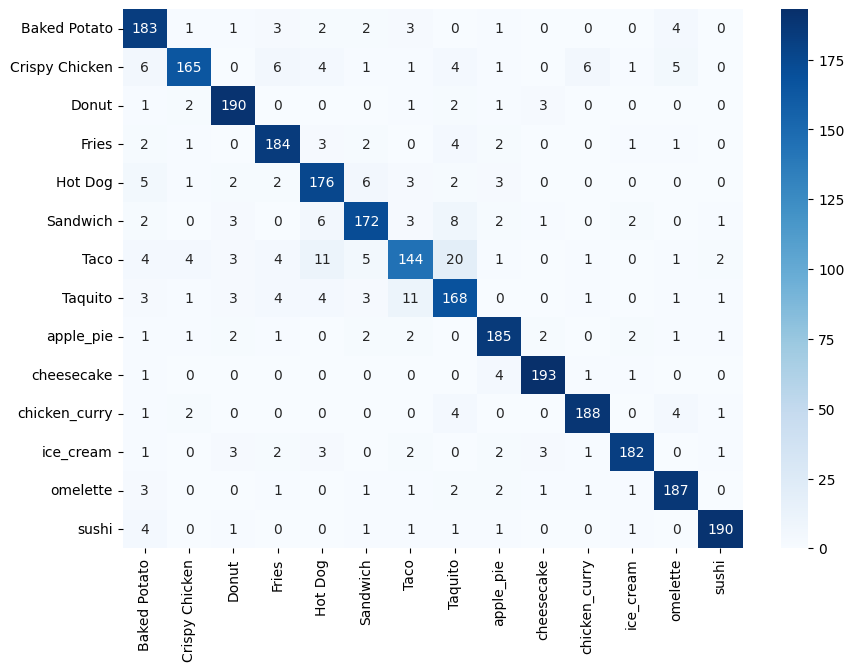

In [ ]:
plot_confusion_matrix(model, testset, device)

Valutando il modello con il dataset di test, otteniamo dei risultati coerenti con quelli visti durante il training. Possiamo dire che il modello ha generalizzato in modo corretto per queste 14 classi.